In [36]:
# Unemployment Analysis with Python

## 1. Import Libraries

## 2. Load Dataset

##3. Data Overview

## 4. Data Cleaning

## 5. Exploratory Data Analysis (EDA)


## 6. Data Visualization

## 7. Key Insights

## 8. Conclusion


In [37]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Display plots inside notebook
%matplotlib inline

In [38]:
# Load Dataset
df = pd.read_csv("Unemployement/archive/Unemployment in India.csv")

# Display first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [39]:
#Data overview
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nDataset Information:")
df.info()

Shape of dataset: (768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(

In [40]:
#Missing Value Analysis
missing_values = df.isnull().sum()
print(missing_values)

#Data cleaning
df = df.dropna()
print("Shape after cleaning:", df.shape)
df.describe()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64
Shape after cleaning: (740, 7)


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [41]:
# Statistical Summary
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


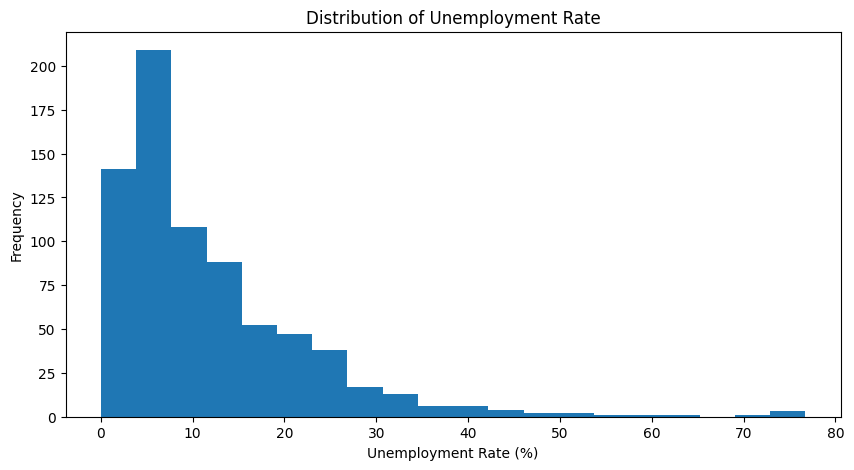

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name:  Estimated Unemployment Rate (%), dtype: float64


In [42]:
# Distribution of Unemployment Rate

#This histogram shows how unemployment rates are distributed across different regions and time periods.
plt.figure(figsize=(10,5))
plt.hist(df[' Estimated Unemployment Rate (%)'], bins=20)
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()
#The unemployment rate distribution is positively skewed. Most observations fall below 15%, while a small number of observations exhibit exceptionally high unemployment rates, creating a long right tail in the distribution.
region_unemployment = df.groupby('Region')[' Estimated Unemployment Rate (%)'].mean()
region_unemployment = region_unemployment.sort_values(ascending=False)
print(region_unemployment.head(10))



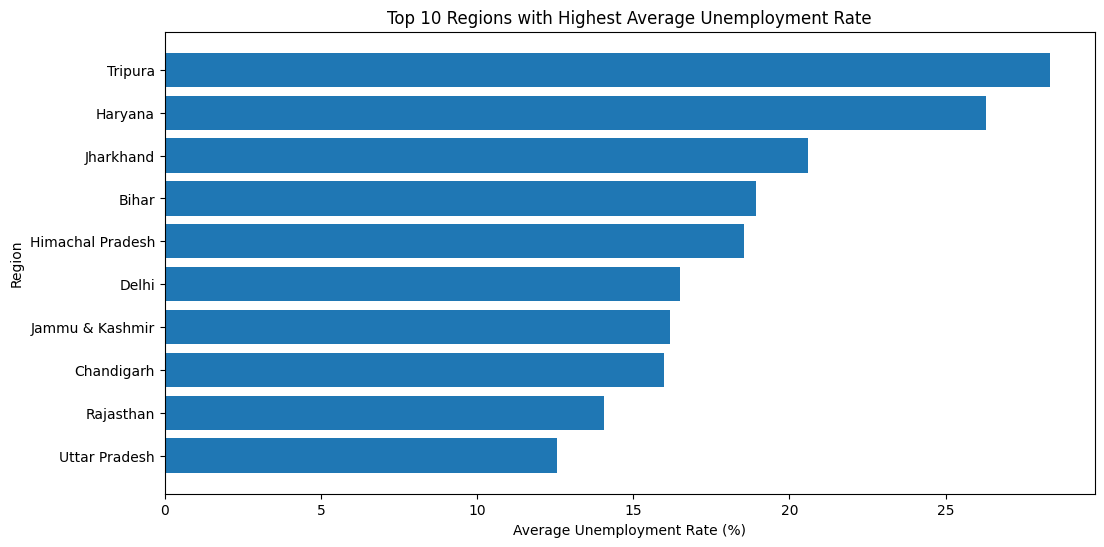

In [43]:
# Top 10 Regions with the Highest Average Unemployment Rate

#This visualization highlights the regions with the highest average unemployment rates during the study period.
top10=region_unemployment.head(10)
plt.figure(figsize=(12,6))
plt.barh(top10.index,top10.values)
plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.gca().invert_yaxis()
plt.show()


Area
Rural    10.324791
Urban    13.166614
Name:  Estimated Unemployment Rate (%), dtype: float64


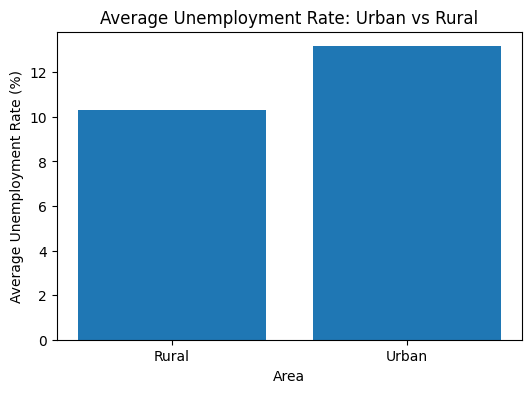

In [44]:
# Urban vs Rural Unemployment Analysis

#This analysis compares the average unemployment rate between urban and rural areas to identify differences in employment patterns.
area_unemployment = df.groupby('Area')[' Estimated Unemployment Rate (%)'].mean()
print(area_unemployment)
plt.figure(figsize=(6,4))
plt.bar(area_unemployment.index,
        area_unemployment.values)
plt.title("Average Unemployment Rate: Urban vs Rural")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()
#The analysis indicates that urban areas experienced a higher average unemployment rate than rural areas during the study period. This suggests differing employment dynamics between urban and rural regions.

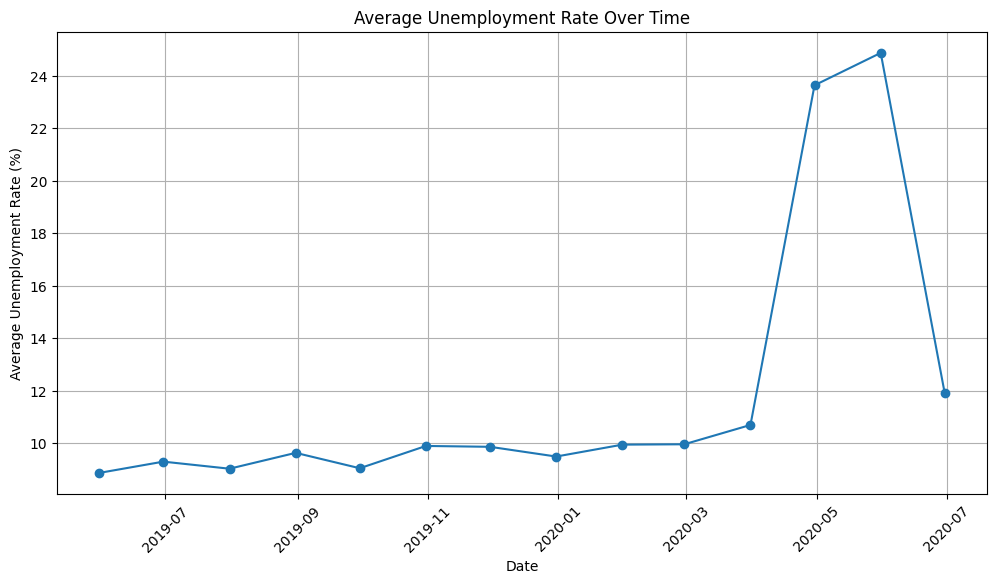

In [45]:
# Unemployment Trend Over Time

#This visualization shows how the average unemployment rate changed over time across all regions.
df[' Date'] = pd.to_datetime(df[' Date'], dayfirst=True)
date_unemployment = df.groupby(' Date')[' Estimated Unemployment Rate (%)'].mean()
date_unemployment = date_unemployment.sort_index()
plt.figure(figsize=(12,6))
plt.plot(date_unemployment.index,
         date_unemployment.values,
         marker='o')

plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()
#The unemployment rate remained relatively stable between 8% and 12% during most periods. However, significant spikes were observed, with unemployment exceeding 23%, indicating periods of economic disruption and employment instability.

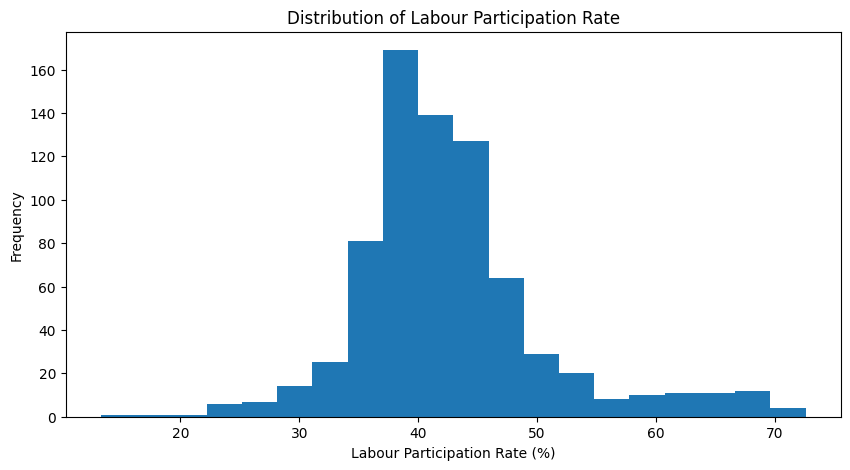

Average Labour Participation Rate: 42.630121621621626


In [46]:
# Labour Participation Rate Analysis

#This section analyzes the distribution of labour participation rates across the dataset.
plt.figure(figsize=(10,5))

plt.hist(df[' Estimated Labour Participation Rate (%)'],
         bins=20)

plt.title('Distribution of Labour Participation Rate')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Frequency')

plt.show()
print("Average Labour Participation Rate:",
      df[' Estimated Labour Participation Rate (%)'].mean())
#The labour participation rate is concentrated around 35%–48%, with an average of 42.63%. Most regions exhibit moderate workforce participation, while a small number of observations show significantly higher participation rates.

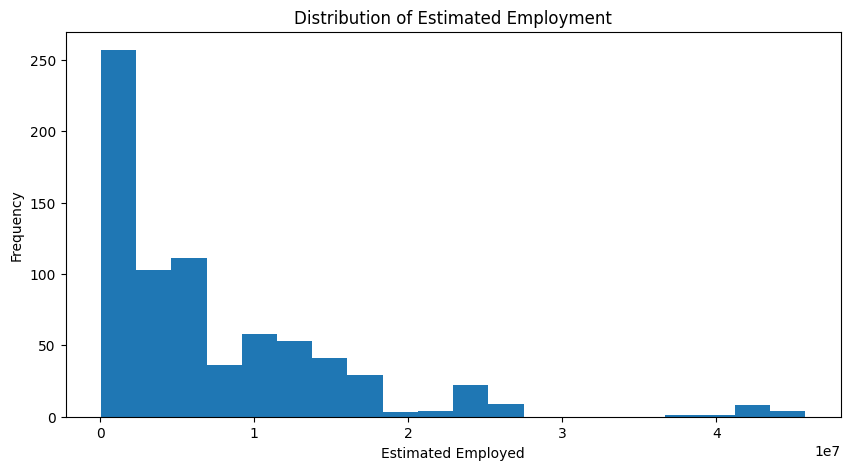

Average Employment: 7204460.025675676


In [47]:
# Employment Distribution Analysis

#This section examines the distribution of estimated employment across regions and periods.
plt.figure(figsize=(10,5))

plt.hist(df[' Estimated Employed'],
         bins=20)

plt.title('Distribution of Estimated Employment')
plt.xlabel('Estimated Employed')
plt.ylabel('Frequency')

plt.show()
print("Average Employment:",
      df[' Estimated Employed'].mean())

In [48]:
# Key Insights

#1. The average unemployment rate across the dataset was approximately 11.79%.

#2. Tripura recorded the highest average unemployment rate (28.35%), followed by Haryana (26.28%) and Jharkhand (20.59%).

#3. Urban areas experienced higher unemployment (13.17%) compared to rural areas (10.32%).

#4. The average labour participation rate was 42.63%, with most observations concentrated between 35% and 48%.

#5. The unemployment trend showed noticeable fluctuations over time, with some periods exhibiting significantly higher unemployment rates than average.

#6. Employment distribution was highly skewed, indicating that a few regions contributed substantially larger workforces than others.

In [49]:
# Conclusion

#This project analyzed unemployment trends in India using Python. After cleaning and exploring the dataset, several important patterns were identified. The analysis revealed notable differences in unemployment rates across regions, higher unemployment in urban areas, and varying levels of labour participation. Trend analysis highlighted periods of elevated unemployment, while employment distribution showed significant variation across regions. These insights can help policymakers and researchers better understand employment dynamics and support informed decision-making.